# EcoHome Energy Advisor - RAG Setup

In this notebook, you'll set up the Retrieval-Augmented Generation (RAG) pipeline for the EcoHome Energy Advisor. This will allow the agent to access and cite relevant energy-saving tips and best practices.

## Learning Objectives
- Set up ChromaDB vector store
- Load and process energy-saving documents
- Create embeddings for document chunks
- Implement semantic search functionality
- Test the RAG pipeline

## Documents Available
- `tip_device_best_practices.txt` - Device-specific optimization tips (starter)
- `tip_energy_savings.txt` - General energy-saving strategies (starter)
- **Nine added documents** covering the five required topics and more:

| Added document | Required topic covered |
|---|---|
| `tip_hvac_optimization.txt` | HVAC optimization strategies |
| `tip_smart_home_automation.txt` | Smart home automation tips |
| `tip_renewable_solar_integration.txt` | Renewable energy integration |
| `tip_seasonal_energy_management.txt` | Seasonal energy management |
| `tip_energy_storage_optimization.txt` | Energy storage optimization |
| `tip_ev_charging_strategies.txt` | EV charging (extra) |
| `tip_time_of_use_rates.txt` | Time-of-use pricing, matches the tariff the pricing tool returns (extra) |
| `tip_water_heating.txt` | Water heating (extra) |
| `tip_pool_spa_energy.txt` | Pools and spas (extra) |

### Beyond basic similarity search (implemented in `rag.py`)
1. **Contextual chunk headers**: every chunk is prefixed with `[Document title > Section]`.
2. **Hybrid retrieval**: dense embeddings (Chroma) plus BM25 keywords, fused with weighted Reciprocal Rank Fusion.
3. **Diversity re-ranking**: at most two chunks per source document in the final results.
4. **Self-refreshing index**: a manifest of document hashes is stored beside the vector store, so adding or
   editing a document triggers a rebuild. (The starter tool indexed a hard-coded list of two files, so
   documents added *after* running this notebook, which is the order the project brief gives, were never searched.)

Section 7 measures whether hybrid retrieval actually beats dense-only and keyword-only search, on two labelled query sets.

## 1. Import Required Libraries

In [1]:
# Import the necessary libraries for RAG setup
import os
from collections import Counter

import pandas as pd
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
# langchain 1.x moved the splitters out of `langchain.text_splitter` into their own package
from langchain_text_splitters import RecursiveCharacterTextSplitter
from dotenv import load_dotenv

import config
import rag

In [2]:
load_dotenv()
print("API key found:", bool(config.get_api_key()), "| base URL:", config.OPENAI_BASE_URL,
      "| embedding model:", config.EMBEDDING_MODEL)

API key found: True | base URL: https://openai.vocareum.com/v1 | embedding model: text-embedding-3-small


## 2. Load and Process Documents

In [3]:
# Load the energy-saving tip documents
# Every .txt/.md file in data/documents is loaded (not a hard-coded list), with UTF-8 decoding
# (the default Windows code page cannot read the degree signs in the documents).

documents = []
document_paths = rag.document_paths()  # data/documents/*.txt|*.md

for doc_path in document_paths:
    if os.path.exists(doc_path):
        # A plain UTF-8 read replaces TextLoader: langchain-community is being sunset and emits a
        # DeprecationWarning on import, and the loader added nothing beyond read + metadata.
        text = doc_path.read_text(encoding="utf-8")
        docs = [Document(page_content=text,
                         metadata={"source": doc_path.name, "title": rag._title_for(doc_path, text)})]
        documents.extend(docs)
        print(f"Loaded {len(docs)} documents from {doc_path.name}")
    else:
        print(f"Warning: {doc_path} not found")

print(f"Total documents loaded: {len(documents)}")

inventory = pd.DataFrame([{
    "source": d.metadata["source"], "title": d.metadata["title"],
    "words": len(d.page_content.split()), "sections": d.page_content.count("\n## "),
} for d in documents])
inventory

Loaded 1 documents from tip_device_best_practices.txt
Loaded 1 documents from tip_energy_savings.txt
Loaded 1 documents from tip_energy_storage_optimization.txt
Loaded 1 documents from tip_ev_charging_strategies.txt
Loaded 1 documents from tip_hvac_optimization.txt
Loaded 1 documents from tip_pool_spa_energy.txt
Loaded 1 documents from tip_renewable_solar_integration.txt
Loaded 1 documents from tip_seasonal_energy_management.txt
Loaded 1 documents from tip_smart_home_automation.txt
Loaded 1 documents from tip_time_of_use_rates.txt
Loaded 1 documents from tip_water_heating.txt
Total documents loaded: 11


,source,title,words,sections
0,tip_device_best_practices.txt,Device Best Practices,277,0
1,tip_energy_savings.txt,Energy Savings,223,0
2,tip_energy_storage_optimization.txt,Home Battery and Energy Storage Optimization,515,7
3,tip_ev_charging_strategies.txt,Electric Vehicle Charging Strategies,527,7
4,tip_hvac_optimization.txt,HVAC Optimization Strategies,665,6
5,tip_pool_spa_energy.txt,Pool and Spa Energy Management,362,6
6,tip_renewable_solar_integration.txt,Renewable Energy Integration: Getting the Most...,607,7
7,tip_seasonal_energy_management.txt,Seasonal Energy Management,482,5
8,tip_smart_home_automation.txt,Smart Home Automation for Energy Savings,553,7
9,tip_time_of_use_rates.txt,Understanding Time-of-Use Electricity Rates,402,6


## 3. Split Documents into Chunks

In [4]:
# Split documents into smaller chunks for better retrieval
# Use RecursiveCharacterTextSplitter with appropriate chunk_size and chunk_overlap
# Experiment with different chunk sizes (e.g., 500, 1000, 1500 characters)

for size in (500, 900, 1500):
    trial = RecursiveCharacterTextSplitter(chunk_size=size, chunk_overlap=int(size * 0.17),
                                           separators=["\n## ", "\n\n", "\n", ". ", " ", ""])
    pieces = trial.split_documents(documents)
    lengths = [len(p.page_content) for p in pieces]
    print(f"chunk_size={size:5d}: {len(pieces):3d} chunks, mean {sum(lengths)/len(lengths):5.0f} chars, "
          f"max {max(lengths)}")

print(f"\nChosen: chunk_size={rag.CHUNK_SIZE}, chunk_overlap={rag.CHUNK_OVERLAP}. Sections in these documents run "
      "500-1,200 characters, so ~900 keeps most sections whole (one idea per chunk) while splitting the long ones.")

# Split on '## ' section boundaries first, then add a contextual header to every chunk
splits = rag.split_documents(documents)
print(f"\nSplit {len(documents)} documents into {len(splits)} chunks")

# Show sample chunk
if splits:
    print(f"\nSample chunk (first 300 characters):")
    print(splits[5].page_content[:300] + "...")

chunk_size=  500:  90 chunks, mean   332 chars, max 490
chunk_size=  900:  49 chunks, mean   612 chars, max 894
chunk_size= 1500:  27 chunks, mean  1123 chars, max 1477

Chosen: chunk_size=900, chunk_overlap=150. Sections in these documents run 500-1,200 characters, so ~900 keeps most sections whole (one idea per chunk) while splitting the long ones.

Split 11 documents into 49 chunks

Sample chunk (first 300 characters):
[Home Battery and Energy Storage Optimization > Operating modes]
## Operating modes
- Self-powered / self-consumption: store surplus solar during the day and use it in the evening. Best when exports earn little (for example under NEM 3.0).
- Time-based control / TOU arbitrage: charge from solar (or ...


## 4. Create Vector Store

In [5]:
# Create a ChromaDB vector store
# Initialize OpenAIEmbeddings
# Create the vector store with the document chunks
# Persist the vector store to disk for future use

# Set up the persist directory
persist_directory = str(config.VECTORSTORE_DIR)
os.makedirs(persist_directory, exist_ok=True)

# Initialize embeddings: the Vocareum gateway, with the key read from .env.
# (The starter passed the literal string "VOCAREUM_API_KEY" as the key, which fails authentication.)
embeddings = OpenAIEmbeddings(
    model=config.EMBEDDING_MODEL,
    base_url=config.OPENAI_BASE_URL,
    api_key=config.get_api_key(),
)
print("embedding dimension:", len(embeddings.embed_query("solar panels")))

# Create the vector store.  rag.build_vectorstore() runs Chroma.from_documents() on the same splits into the
# collection the agent's search tool reads, and writes the manifest that lets the tool detect new documents.
vectorstore, n_docs, n_chunks = rag.build_vectorstore(persist_directory)

print(f"Vector store created and persisted to {persist_directory}")
print(f"Total vectors stored: {vectorstore._collection.count()} (from {n_docs} documents, {n_chunks} chunks)")
print("Index current with documents on disk:", rag.vectorstore_is_current())

embedding dimension: 1536


Vector store created and persisted to C:\Users\tarie\source\repos\Woolf\ecohome-energy-advisor\ecohome_solution\data\vectorstore
Total vectors stored: 49 (from 11 documents, 49 chunks)
Index current with documents on disk: True


## 5. Test the RAG Pipeline

In [6]:
# Test the search functionality
# Try different queries related to energy optimization

test_queries = [
    "electric vehicle charging tips",
    "thermostat optimization",
    "dishwasher energy saving",
    "solar power maximization",
    "HVAC system efficiency",
    "pool pump scheduling"
]

print("=== Testing Vector Search ===")
for query in test_queries:
    print(f"\nQuery: '{query}'")
    docs = vectorstore.similarity_search_with_relevance_scores(query, k=2)
    for i, (doc, score) in enumerate(docs):
        print(f"  Result {i+1} [{doc.metadata['source']}, similarity {score:.3f}]: "
              f"{doc.page_content[:100].replace(chr(10), ' ')}...")

=== Testing Vector Search ===

Query: 'electric vehicle charging tips'


  Result 1 [tip_ev_charging_strategies.txt, similarity 0.664]: [Electric Vehicle Charging Strategies > Electric Vehicle Charging Strategies] # Electric Vehicle Cha...
  Result 2 [tip_ev_charging_strategies.txt, similarity 0.653]: [Electric Vehicle Charging Strategies > Cheapest time to charge] ## Cheapest time to charge - On tim...

Query: 'thermostat optimization'


  Result 1 [tip_hvac_optimization.txt, similarity 0.641]: [HVAC Optimization Strategies > Thermostat setpoints that balance comfort and cost] ## Thermostat se...
  Result 2 [tip_smart_home_automation.txt, similarity 0.550]: [Smart Home Automation for Energy Savings > Smart Home Automation for Energy Savings] # Smart Home A...

Query: 'dishwasher energy saving'


  Result 1 [tip_device_best_practices.txt, similarity 0.569]: [Device Best Practices] Dishwasher Best Practices: - Only run when completely full - Use the energy-...
  Result 2 [tip_energy_savings.txt, similarity 0.509]: [Energy Savings] Saving energy at home can be simple and effective. Turn off lights when not in use ...

Query: 'solar power maximization'


  Result 1 [tip_renewable_solar_integration.txt, similarity 0.553]: [Renewable Energy Integration: Getting the Most from Rooftop Solar > Renewable Energy Integration: G...
  Result 2 [tip_renewable_solar_integration.txt, similarity 0.537]: [Renewable Energy Integration: Getting the Most from Rooftop Solar > Keeping the system productive] ...

Query: 'HVAC system efficiency'


  Result 1 [tip_hvac_optimization.txt, similarity 0.640]: [HVAC Optimization Strategies > Maintenance that preserves efficiency] ## Maintenance that preserves...
  Result 2 [tip_hvac_optimization.txt, similarity 0.628]: [HVAC Optimization Strategies > Choosing equipment] ## Choosing equipment - Modern heat pumps provid...

Query: 'pool pump scheduling'


  Result 1 [tip_pool_spa_energy.txt, similarity 0.588]: [Pool and Spa Energy Management > Pool and Spa Energy Management] # Pool and Spa Energy Management  ...
  Result 2 [tip_pool_spa_energy.txt, similarity 0.581]: [Pool and Spa Energy Management > When to run the pump] ## When to run the pump - Run the pump durin...


## 6. Test the Search Tool

In [7]:
# Test the search_energy_tips tool from tools.py
# Import and test the tool with various queries
# Verify that it returns relevant results

from tools import search_energy_tips

# Test the search_energy_tips function
print("=== Testing search_energy_tips Tool ===")

test_queries = [
    "electric vehicle charging",
    "thermostat settings",
    "dishwasher optimization",
    "solar power tips",
    "home battery during peak hours",
    "what to do in winter",
]

for query in test_queries:
    print(f"\nQuery: '{query}'")
    result = search_energy_tips.invoke(
        input={
            "query": query,
            "max_results": 3,
        }
    )

    if "error" in result:
        print(f"  Error: {result['error']}")
    else:
        print(f"  Found {result['total_results']} results ({result['search_method']}; index {result['index_status']})")
        for i, tip in enumerate(result['tips']):
            print(f"    {i+1}. {tip['content'][:100].replace(chr(10), ' ')}...")
            print(f"       Source: {tip['source']}")
            print(f"       Relevance: {tip['relevance_score']} (fused {tip['fused_score']}, "
                  f"vector {tip['vector_similarity']}, keyword {tip['keyword_score']})")

=== Testing search_energy_tips Tool ===

Query: 'electric vehicle charging'


  Found 3 results (hybrid (dense embeddings + BM25, reciprocal rank fusion, per-source diversity); index loaded)
    1. [Electric Vehicle Charging Strategies > Electric Vehicle Charging Strategies] # Electric Vehicle Cha...
       Source: tip_ev_charging_strategies.txt
       Relevance: high (fused 1.0, vector 0.6828, keyword 1.0)
    2. [Electric Vehicle Charging Strategies > Managed charging programs] ## Managed charging programs - Ma...
       Source: tip_ev_charging_strategies.txt
       Relevance: high (fused 0.979, vector 0.6301, keyword 0.9328)
    3. [Renewable Energy Integration: Getting the Most from Rooftop Solar > Solar plus electric vehicles] #...
       Source: tip_renewable_solar_integration.txt
       Relevance: high (fused 0.934, vector 0.5677, keyword 0.7802)

Query: 'thermostat settings'


  Found 3 results (hybrid (dense embeddings + BM25, reciprocal rank fusion, per-source diversity); index cached)
    1. [HVAC Optimization Strategies > Thermostat setpoints that balance comfort and cost] ## Thermostat se...
       Source: tip_hvac_optimization.txt
       Relevance: high (fused 1.0, vector 0.6094, keyword 1.0)
    2. [Smart Home Automation for Energy Savings > Smart Home Automation for Energy Savings] # Smart Home A...
       Source: tip_smart_home_automation.txt
       Relevance: high (fused 0.979, vector 0.4853, keyword 0.3403)
    3. [Water Heating Efficiency > Water Heating Efficiency] # Water Heating Efficiency  Water heating is o...
       Source: tip_water_heating.txt
       Relevance: high (fused 0.944, vector 0.4345, keyword 0.4564)

Query: 'dishwasher optimization'


  Found 3 results (hybrid (dense embeddings + BM25, reciprocal rank fusion, per-source diversity); index cached)
    1. [Device Best Practices] Dishwasher Best Practices: - Only run when completely full - Use the energy-...
       Source: tip_device_best_practices.txt
       Relevance: high (fused 1.0, vector 0.5572, keyword 0.7846)
    2. [Device Best Practices] Large devices like electric vehicles, washing machines and dishwashers often...
       Source: tip_device_best_practices.txt
       Relevance: high (fused 0.994, vector 0.4709, keyword 0.8231)
    3. [Smart Home Automation for Energy Savings > Scheduling flexible loads] ## Scheduling flexible loads ...
       Source: tip_smart_home_automation.txt
       Relevance: high (fused 0.989, vector 0.4543, keyword 0.8464)

Query: 'solar power tips'


  Found 3 results (hybrid (dense embeddings + BM25, reciprocal rank fusion, per-source diversity); index cached)
    1. [Home Battery and Energy Storage Optimization > Estimating savings] ## Estimating savings - Daily ar...
       Source: tip_energy_storage_optimization.txt
       Relevance: high (fused 1.0, vector 0.5064, keyword 1.0)
    2. [Renewable Energy Integration: Getting the Most from Rooftop Solar > Solar plus electric vehicles] #...
       Source: tip_renewable_solar_integration.txt
       Relevance: high (fused 0.999, vector 0.5119, keyword 0.6093)
    3. [Home Battery and Energy Storage Optimization > Daily strategy for a solar home on time-of-use rates...
       Source: tip_energy_storage_optimization.txt
       Relevance: high (fused 0.989, vector 0.5296, keyword 0.5353)

Query: 'home battery during peak hours'


  Found 3 results (hybrid (dense embeddings + BM25, reciprocal rank fusion, per-source diversity); index cached)
    1. [Home Battery and Energy Storage Optimization > Daily strategy for a solar home on time-of-use rates...
       Source: tip_energy_storage_optimization.txt
       Relevance: high (fused 1.0, vector 0.6443, keyword 0.8926)
    2. [Home Battery and Energy Storage Optimization > Operating modes] ## Operating modes - Self-powered /...
       Source: tip_energy_storage_optimization.txt
       Relevance: high (fused 0.97, vector 0.5944, keyword 0.6527)
    3. [HVAC Optimization Strategies > Pre-cooling and pre-heating around peak prices] ## Pre-cooling and p...
       Source: tip_hvac_optimization.txt
       Relevance: high (fused 0.932, vector 0.5575, keyword 0.5694)

Query: 'what to do in winter'


  Found 3 results (hybrid (dense embeddings + BM25, reciprocal rank fusion, per-source diversity); index cached)
    1. [Seasonal Energy Management > Winter (heating season)] ## Winter (heating season) - Set heating to 6...
       Source: tip_seasonal_energy_management.txt
       Relevance: high (fused 1.0, vector 0.4404, keyword 0.7211)
    2. [Seasonal Energy Management > Autumn (shoulder season)] ## Autumn (shoulder season) - Mild temperatu...
       Source: tip_seasonal_energy_management.txt
       Relevance: high (fused 0.955, vector 0.3823, keyword 0.4802)
    3. [HVAC Optimization Strategies > Pre-cooling and pre-heating around peak prices] - Well-insulated hom...
       Source: tip_hvac_optimization.txt
       Relevance: high (fused 0.935, vector 0.2875, keyword 0.5732)


## 7. Does Hybrid Retrieval Help? A Retrieval Benchmark

Two labelled query sets, each question tagged with the document that should answer it:

- **conversational** (20): questions phrased the way customers talk ("Should I cool the house down before prices go up?")
- **exact-term** (16): jargon and product terms ("SEER2 and HSPF2 ratings", "NEM 3.0", "V2H"), which is how the agent
  itself tends to phrase `search_energy_tips` queries

Three retrievers are compared by the rank of the first chunk from the correct document:

- **dense**: Chroma cosine similarity only
- **BM25**: keyword ranking only
- **hybrid**: weighted Reciprocal Rank Fusion of both, with the per-source diversity cap (what the agent uses)

Metrics: Hit@1, Hit@3 and Mean Reciprocal Rank (MRR@5).

In [8]:
conversational = [
    ("How warm should I let the house get during the 4-9pm price peak?", "tip_hvac_optimization.txt"),
    ("Is it worth sealing my ducts?", "tip_hvac_optimization.txt"),
    ("Should I cool the house down before prices go up?", "tip_hvac_optimization.txt"),
    ("Can my thermostat use my phone's location to save energy?", "tip_smart_home_automation.txt"),
    ("How much power do devices use when they are switched off?", "tip_smart_home_automation.txt"),
    ("Why is exporting solar to the grid worth so little under NEM 3.0?", "tip_renewable_solar_integration.txt"),
    ("My panels produced 20% less than last week, what could be wrong?", "tip_renewable_solar_integration.txt"),
    ("What should I change about my energy habits when winter comes?", "tip_seasonal_energy_management.txt"),
    ("Spring maintenance checklist for my air conditioner and panels", "tip_seasonal_energy_management.txt"),
    ("Is it worth charging my Powerwall from the grid at night?", "tip_energy_storage_optimization.txt"),
    ("How much backup reserve should my battery keep?", "tip_energy_storage_optimization.txt"),
    ("How many miles of range does a Level 2 charger add per hour?", "tip_ev_charging_strategies.txt"),
    ("Should I charge my car to 100 percent every night?", "tip_ev_charging_strategies.txt"),
    ("When is electricity cheapest on my rate plan?", "tip_time_of_use_rates.txt"),
    ("What is a critical peak event?", "tip_time_of_use_rates.txt"),
    ("What temperature should my water heater be set to?", "tip_water_heating.txt"),
    ("Are heat pump water heaters more efficient?", "tip_water_heating.txt"),
    ("How many hours a day should my pool pump run?", "tip_pool_spa_energy.txt"),
    ("Does a pool cover really save money?", "tip_pool_spa_energy.txt"),
    ("Should I use cold water for laundry?", "tip_device_best_practices.txt"),
]
exact_term = [
    ("SEER2 and HSPF2 ratings", "tip_hvac_optimization.txt"),
    ("Manual J load calculation", "tip_hvac_optimization.txt"),
    ("NEM 3.0 net billing tariff", "tip_renewable_solar_integration.txt"),
    ("LFP cycle life", "tip_energy_storage_optimization.txt"),
    ("V2H vehicle-to-home backup", "tip_energy_storage_optimization.txt"),
    ("WaterSense 2.0 gpm showerhead", "tip_water_heating.txt"),
    ("anode rod", "tip_water_heating.txt"),
    ("phantom load power strips", "tip_smart_home_automation.txt"),
    ("geofencing thermostat", "tip_smart_home_automation.txt"),
    ("Flex Alert demand response", "tip_smart_home_automation.txt"),
    ("R-38 attic insulation", "tip_hvac_optimization.txt"),
    ("DC fast charging", "tip_ev_charging_strategies.txt"),
    ("Level 1 120 V outlet", "tip_ev_charging_strategies.txt"),
    ("thermostatic mixing valve", "tip_water_heating.txt"),
    ("night flushing", "tip_seasonal_energy_management.txt"),
    ("lint filter moisture sensor", "tip_energy_savings.txt"),
]

store, _ = rag.get_vectorstore()
bm25, all_chunks = rag._bm25_index(store, str(config.VECTORSTORE_DIR))

def first_rank(sources, target):
    for i, s in enumerate(sources, 1):
        if s == target:
            return i
    return None

def dense_sources(q):
    return [d.metadata["source"] for d in store.similarity_search(q, k=5)]

def bm25_sources(q):
    scores = bm25.get_scores(rag.tokenize(q))
    order = sorted(range(len(all_chunks)), key=lambda i: scores[i], reverse=True)[:5]
    return [all_chunks[i].metadata["source"] for i in order]

def hybrid_sources(q):
    return [h["doc"].metadata["source"] for h in rag.hybrid_search(q, k=5)["results"]]

rows = []
for set_name, queries in (("conversational", conversational), ("exact-term", exact_term)):
    for q, target in queries:
        row = {"set": set_name, "query": q, "expected": target}
        for name, fn in (("dense", dense_sources), ("bm25", bm25_sources), ("hybrid", hybrid_sources)):
            row[name] = first_rank(fn(q), target)
        rows.append(row)
bench = pd.DataFrame(rows)

def summarise(frame, col):
    r = frame[col]
    return {"Hit@1": (r == 1).mean(), "Hit@3": (r <= 3).mean(),
            "MRR@5": r.map(lambda x: 0 if pd.isna(x) else 1 / x).mean()}

tables = {}
for set_name, frame in (("conversational", bench[bench.set == "conversational"]),
                        ("exact-term", bench[bench.set == "exact-term"]), ("all 36", bench)):
    tables[set_name] = pd.DataFrame({c: summarise(frame, c) for c in ("dense", "bm25", "hybrid")}).T.round(3)
retrieval_scores = pd.concat(tables, axis=1)
retrieval_scores

conversational              exact-term               all 36         \
                Hit@1 Hit@3  MRR@5      Hit@1  Hit@3  MRR@5  Hit@1  Hit@3   
dense            0.90  1.00  0.942      0.812  0.938  0.865  0.861  0.972   
bm25             0.55  0.90  0.710      1.000  1.000  1.000  0.750  0.944   
hybrid           0.85  0.95  0.912      0.938  1.000  0.958  0.889  0.972   

               
        MRR@5  
dense   0.907  
bm25    0.839  
hybrid  0.933

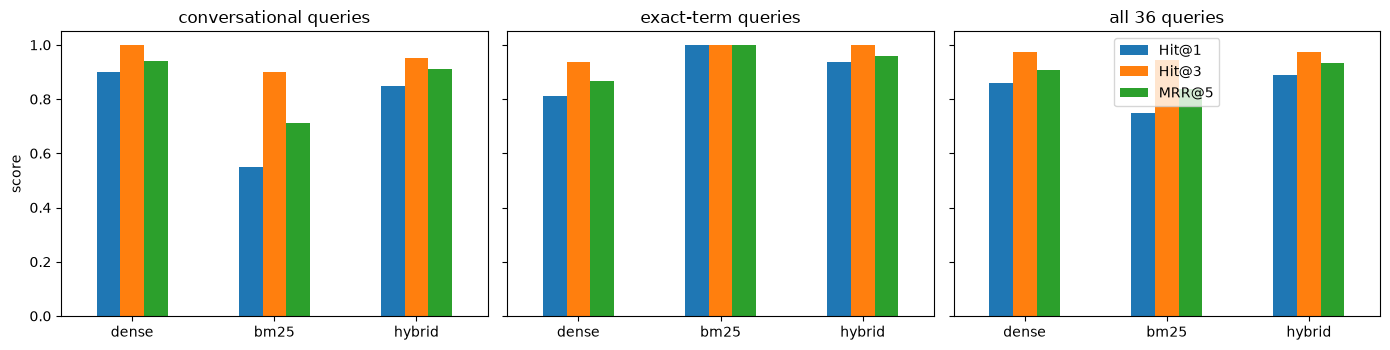

Queries where hybrid did not rank the expected document first:
           set                                                     query                            expected  dense  bm25  hybrid
conversational Is it worth charging my Powerwall from the grid at night? tip_energy_storage_optimization.txt    1.0   3.0       2
conversational                            What is a critical peak event?           tip_time_of_use_rates.txt    3.0   3.0       4
conversational                      Should I use cold water for laundry?       tip_device_best_practices.txt    2.0   5.0       2
    exact-term                               lint filter moisture sensor              tip_energy_savings.txt    NaN   1.0       3


In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for ax, (name, t) in zip(axes, tables.items()):
    t.plot(kind="bar", ax=ax, rot=0, ylim=(0, 1.05), title=f"{name} queries", legend=(name == "all 36"))
axes[0].set_ylabel("score"); plt.tight_layout()
(config.REPORTS_DIR / "figures").mkdir(parents=True, exist_ok=True)
plt.savefig(config.REPORTS_DIR / "figures" / "02_retrieval_benchmark.png", dpi=110); plt.show()

misses = bench[(bench.hybrid.isna()) | (bench.hybrid > 1)]
print("Queries where hybrid did not rank the expected document first:")
print(misses.to_string(index=False) if len(misses) else "  none")

**Reading the benchmark honestly.** The two retrievers fail in different places:

- On **conversational** questions, dense embeddings are the strongest single ranker. BM25 is weak because customers
  rarely use the documents' vocabulary. Hybrid lands close to dense, but not above it.
- On **exact-term** questions, BM25 is best and dense misses several: acronyms such as SEER2, V2H and NEM carry little
  semantic signal for an embedding model. Hybrid recovers most of those misses.
- **Across all 36 questions hybrid is the most robust choice**, which is why `search_energy_tips` uses it. The agent's own
  tool queries are short and keyword-like ("EV charging off-peak", "pre-cooling setpoints"), closer to the exact-term set.

Two changes came directly out of this benchmark. The BM25 tokeniser originally kept hyphens and trailing periods
(`critical-peak`, `peak.`), so exact terms never matched; that was fixed. RRF is also **weighted** (dense 1.0, BM25 0.5):
with equal weights, a weak keyword ranking could push a dense rank-1 hit out of the top five. Caveat: 36 labelled questions
is a small benchmark, so treat differences of one or two questions as noise.

## 8. The Index Keeps Itself Current

The brief asks for documents to be added *after* this notebook runs. The tool compares a hash of every file in
`data/documents` with the manifest saved beside the vector store and rebuilds when they differ. Adding a temporary
document here shows the rebuild happen, then removes the document and restores the index.

In [10]:
tmp_doc = config.DOCUMENTS_DIR / "tip_zz_temporary_demo.txt"
tmp_doc.write_text("# Induction Cooking\n\nInduction cooktops transfer about 85% of their energy into the pan, "
                   "versus roughly 32% for gas burners.", encoding="utf-8")
try:
    print("index current after adding a document?", rag.vectorstore_is_current())
    r = search_energy_tips.invoke({"query": "induction cooktop efficiency", "max_results": 2})
    print("index status:", r["index_status"], "| top source:", r["tips"][0]["source"])
finally:
    tmp_doc.unlink()
r = search_energy_tips.invoke({"query": "induction cooktop efficiency", "max_results": 2})
print("after removal -> index status:", r["index_status"], "| top source:", r["tips"][0]["source"])
print("final index current:", rag.vectorstore_is_current(), "| chunks:", rag.get_vectorstore()[0]._collection.count())

index current after adding a document? False


index status: rebuilt | top source: tip_zz_temporary_demo.txt


after removal -> index status: rebuilt | top source: tip_water_heating.txt
final index current: True | chunks: 49


## Summary

- The knowledge base holds **11 documents** (2 starter + 9 added) covering all five required topics plus EV charging,
  time-of-use rates, water heating and pools.
- Chunks carry contextual headers; retrieval is hybrid (dense + BM25 with weighted RRF) with a per-source diversity cap.
- The benchmark shows dense is strongest on conversational questions and BM25 on exact terms; weighted hybrid is the
  most robust across both.
- `search_energy_tips` returns a results dict with rank, content, source, title, section and scores, so the agent can cite its sources.